 ## Ex 01 - Developing a Neural Network Regression Model 
**Name:** Ekkaluri Mythri

**Reg.No:** 212223240034

**Slot:**  26OD1143

In [3]:
import torch
import torch.nn as nn
import numpy as np 
import matplotlib.pyplot as plt


In [4]:
X = torch.linspace(1,50,50).reshape(-1,1)

In [8]:
torch.manual_seed(55)
e = torch.randint(-8,9,(50,1),dtype=torch.float)

In [10]:
y = 2*X + 1 + e
print(y.shape)

torch.Size([50, 1])


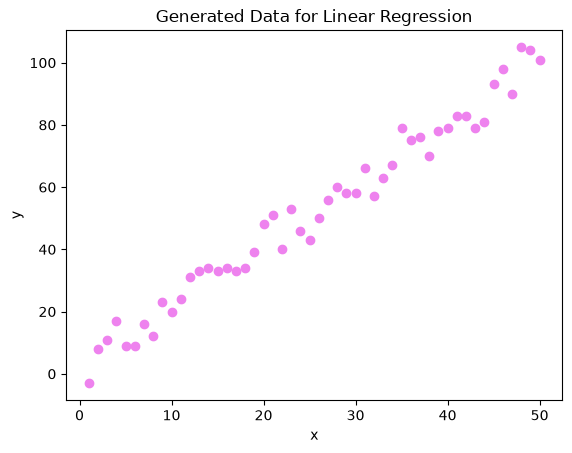

In [12]:
plt.scatter(X.numpy(), y.numpy(),color='violet')  
plt.xlabel('x')
plt.ylabel('y')
plt.title('Generated Data for Linear Regression')
plt.show()

In [13]:
# Setting a manual seed for reproducibility
torch.manual_seed(59)

# Defining the model class
class Model(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.linear = nn.Linear(in_features, out_features)
        
    def forward(self, x):
        y_pred = self.linear(x)
        return y_pred

In [14]:
torch.manual_seed(59)
model = Model(1, 1)

In [15]:
criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr = 0.001)

In [16]:
epochs = 50 
losses = []
for i in range(epochs):
    i = i +1 
    # Predicting on the Forward Pass   
    y_pred = model.forward(X)
    # Calculating our Loss(error) 
    loss = criterion(y_pred, y)
    # Recording that error
    losses.append(loss.item())
    print(f'epoch: {i}  loss: {loss.item()}  weight: {model.linear.weight.item()} bias: {model.linear.bias.item()}') 
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

epoch: 1  loss: 3085.322509765625  weight: 0.10597813129425049 bias: 0.9637961387634277
epoch: 2  loss: 1603.1837158203125  weight: 3.3496603965759277 bias: 1.0607436895370483
epoch: 3  loss: 838.0072631835938  weight: 1.0189955234527588 bias: 0.9920695424079895
epoch: 4  loss: 442.9739990234375  weight: 2.693584680557251 bias: 1.0423966646194458
epoch: 5  loss: 239.03236389160156  weight: 1.4903373718261719 bias: 1.0072190761566162
epoch: 6  loss: 133.74436950683594  weight: 2.3548600673675537 bias: 1.0334774255752563
epoch: 7  loss: 79.3877182006836  weight: 1.733657956123352 bias: 1.0155925750732422
epoch: 8  loss: 51.325164794921875  weight: 2.179971933364868 bias: 1.029424786567688
epoch: 9  loss: 36.83732223510742  weight: 1.8592593669891357 bias: 1.0204674005508423
epoch: 10  loss: 29.357593536376953  weight: 2.0896670818328857 bias: 1.0278842449188232
epoch: 11  loss: 25.495929718017578  weight: 1.924086570739746 bias: 1.0235354900360107
epoch: 12  loss: 23.502138137817383  wei

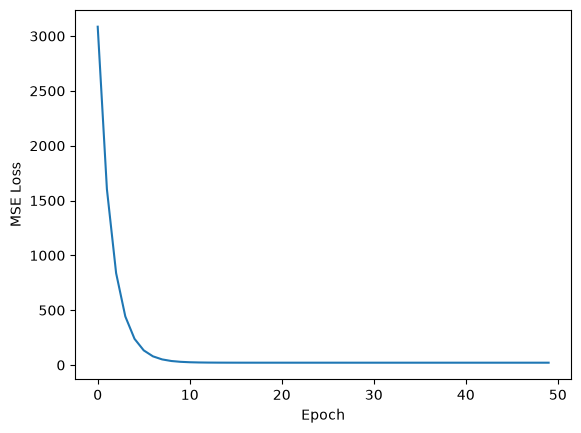

In [17]:
plt.plot(range(epochs), losses)
plt.ylabel('MSE Loss')
plt.xlabel('Epoch')
plt.show()

In [18]:
x = np.linspace(0.0,50.0,50)
current_weight = model.linear.weight.item()
current_bias = model.linear.bias.item()

predicted_y = current_weight * x + current_bias

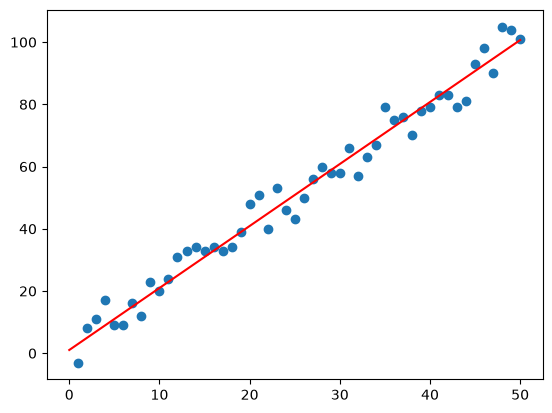

In [20]:
plt.scatter(X, y)
plt.plot(x,predicted_y, 'r')